In [1]:
%cd ../

/Users/paulb/Desktop/code/research/babi


In [2]:
from data import constants
import pandas as pd
import os
import numpy as np

In [3]:
# parse capnostream to get CO2 waveform and timestamps
file_path = os.path.join(constants.raw_data_dir, "package/co2.xlsx")
raw_capnostream_df = pd.read_excel(file_path)
data_start_row = 6
waveform_extracted_time = raw_capnostream_df.iloc[data_start_row:, 1].reset_index(drop=True)
waveform_extracted_value = raw_capnostream_df.iloc[data_start_row:, 2].reset_index(drop=True).map(lambda x: float(x) if isinstance(x, (int, float)) else -1)
co2_not_available = raw_capnostream_df.iloc[data_start_row:, 16].reset_index(drop=True).to_numpy()

co2_range = np.where(co2_not_available == 0)[0]
waveform = waveform_extracted_value.to_numpy()[co2_range]
waveform_timestamps = waveform_extracted_time.to_numpy()[co2_range]

print(f"Waveform start: {waveform_timestamps[0]}, end: {waveform_timestamps[-1]}")
print(waveform.shape)

Waveform start: 09:04:56, end: 09:32:39
(33064,)


In [4]:
# parse mocap
file_path = os.path.normpath(os.path.join(constants.raw_data_dir, "package/mocap.tsv"))

mocap_start_time = pd.to_datetime("09:13:06.541")
mocap_df = pd.read_csv(file_path, sep="\t", header=10, usecols=[i +2 for i in range(69)])
motion = mocap_df.values.reshape(mocap_df.shape[0], -1, 3)
print(f"Motion start: {mocap_start_time.time()}, end: {(mocap_start_time + pd.to_timedelta(motion.shape[0] / 100, unit='s')).time()}")
motion.shape

Motion start: 09:13:06.541000, end: 09:15:10.761000


(12422, 23, 3)

In [ ]:
import numpy as np
import scipy.signal
from sklearn.decomposition import PCA

def align_signals(co2_signal, mocap_data, mocap_fs=100, co2_fs=20):
    
    # 1. Feature Extraction: Reduce MoCap to 1D via PCA
    if mocap_data.ndim > 2:
        # Flatten (Frames, Markers, 3) -> (Frames, Features)
        mocap_reshaped = mocap_data.reshape(mocap_data.shape[0], -1)
    else:
        mocap_reshaped = mocap_data
        
    pca = PCA(n_components=1)
    # fit_transform returns (N, 1), flatten to (N,)
    mocap_1d = pca.fit_transform(mocap_reshaped).flatten()

    # 2. Resampling: Downsample MoCap (100Hz) to CO2 (20Hz)
    num_samples = int(len(mocap_1d) * (co2_fs / mocap_fs))
    mocap_resampled = scipy.signal.resample(mocap_1d, num_samples)

    # 3. Normalization (Z-score)
    # Critical for amplitude independence
    co2_norm = (co2_signal - np.mean(co2_signal)) / np.std(co2_signal)
    mocap_norm = (mocap_resampled - np.mean(mocap_resampled)) / np.std(mocap_resampled)

    # 4. Cross-Correlation (mode='valid')
    # This slides the shorter signal (mocap) along the longer signal (co2).
    # It only computes values where they fully overlap.
    correlation = scipy.signal.correlate(co2_norm, mocap_norm, mode='valid')
    
    # Lags for 'valid' mode are different. 
    # They represent the shift of the second signal relative to the first.
    lags = scipy.signal.correlation_lags(len(co2_norm), len(mocap_norm), mode='valid')

    # 5. Find Optimal Alignment
    # Find the index of the maximum absolute correlation
    lag_index = np.argmax(np.abs(correlation))
    optimal_lag = lags[lag_index]
    
    # 6. Calculate Time Shift
    # optimal_lag is the number of samples the MoCap signal is shifted.
    # If positive, MoCap starts AFTER the CO2 start.
    time_shift = optimal_lag / co2_fs
    
    # Check polarity
    is_inverted = correlation[lag_index] < 0
    
    return time_shift, is_inverted

In [6]:
import numpy as np
import scipy.signal
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """
    Applies a Butterworth bandpass filter to isolate breathing frequencies.
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = scipy.signal.butter(order, [low, high], btype='band')
    y = scipy.signal.filtfilt(b, a, data)
    return y

def normalize_signal(signal):
    """
    Z-score normalization: (x - mean) / std.
    Centers signal at 0 and scales amplitude to 1.
    """
    return (signal - np.mean(signal)) / np.std(signal)

def resample_signal(signal, original_fs, target_fs):
    """
    Resamples a signal from original_fs to target_fs.
    """
    if original_fs == target_fs:
        return signal
    num_samples = int(len(signal) * (target_fs / original_fs))
    return scipy.signal.resample(signal, num_samples)

def get_best_correlation(long_sig, short_sig, fs):
    """
    Correlates a short signal against a long signal.
    Returns: (max_correlation_score, time_shift_seconds, is_inverted)
    """
    # Use 'valid' mode because short_sig is a subset of long_sig
    correlation = scipy.signal.correlate(long_sig, short_sig, mode='valid')
    lags = scipy.signal.correlation_lags(len(long_sig), len(short_sig), mode='valid')
    
    # Find absolute peak (magnitude)
    peak_idx = np.argmax(np.abs(correlation))
    max_corr = np.abs(correlation[peak_idx])
    optimal_lag = lags[peak_idx]
    
    # Calculate physics
    time_shift = optimal_lag / fs
    is_inverted = correlation[peak_idx] < 0
    
    return max_corr, time_shift, is_inverted

In [ ]:
def align_signals_robust(co2_raw, mocap_raw, mocap_fs=100, co2_fs=20, low_freq=0.1, high_freq=0.8):
    # --- A. Pre-process CO2 (The Reference) ---
    # Filter CO2 first to remove sensor drift/noise
    co2_filtered = butter_bandpass_filter(co2_raw, low_freq, high_freq, co2_fs)
    co2_norm = normalize_signal(co2_filtered)

    # --- B. Pre-process MoCap (The Candidate) ---
    # 1. Flatten spatial dimensions
    if mocap_raw.ndim > 2:
        mocap_reshaped = mocap_raw.reshape(mocap_raw.shape[0], -1)
    else:
        mocap_reshaped = mocap_raw
        
    # 2. Run PCA to get top 3 components
    # We check 3 because PC1 might be artifacts (spikes/posture)
    n_components = min(8, mocap_reshaped.shape[1])
    pca = PCA(n_components=n_components)
    mocap_pcs = pca.fit_transform(mocap_reshaped) # Shape: (N, 3)

    # --- C. Search for Best Alignment ---
    best_result = {
        'correlation_score': -1,
        'time_shift': 0,
        'is_inverted': False,
        'best_component': 0
    }

    print(f"Searching top {n_components} PCA components...")
    
    for i in range(n_components):
        # Extract single component
        pc_signal = mocap_pcs[:, i]
        
        # 1. Resample to match CO2 (100Hz -> 20Hz)
        pc_resampled = resample_signal(pc_signal, mocap_fs, co2_fs)
        
        # 2. Filter (Critical: removes the "large spike" artifacts)
        pc_filtered = butter_bandpass_filter(pc_resampled, low_freq, high_freq, co2_fs)
        
        # 3. Normalize
        pc_norm = normalize_signal(pc_filtered)
        
        # 4. Correlate
        score, shift, inverted = get_best_correlation(co2_norm, pc_norm, co2_fs)
        
        print(f"  > PC{i+1}: Score={score:.3f}, Shift={shift:.2f}s, Inverted={inverted}")
        
        # 5. Keep if better
        if score > best_result['correlation_score']:
            best_result['correlation_score'] = score
            best_result['time_shift'] = shift
            best_result['is_inverted'] = inverted
            best_result['best_component'] = i

    print(f"Winner: PC{best_result['best_component']+1} "
          f"(Shift: {best_result['time_shift']:.3f}s)")
            
    return best_result

In [ ]:
def plot_final_alignment(co2_raw, mocap_raw, alignment_result, 
                         mocap_fs=100, co2_fs=20, 
                         low_freq=0.1, high_freq=0.8):
    """
    Visualizes the result of align_signals_robust.
    Recreates the exact processing steps of the winning component.
    """
    shift = alignment_result['time_shift']
    comp_idx = alignment_result['best_component']
    inverted = alignment_result['is_inverted']
    
    # --- Re-Process CO2 ---
    co2_filt = butter_bandpass_filter(co2_raw, low_freq, high_freq, co2_fs)
    co2_norm = normalize_signal(co2_filt)
    
    # --- Re-Process MoCap (Winner Only) ---
    if mocap_raw.ndim > 2:
        mocap_reshaped = mocap_raw.reshape(mocap_raw.shape[0], -1)
    else:
        mocap_reshaped = mocap_raw

    pca = PCA(n_components=comp_idx + 1) # Fit up to the winner
    mocap_pcs = pca.fit_transform(mocap_reshaped)
    pc_signal = mocap_pcs[:, comp_idx] # Select the winner
    
    pc_resampled = resample_signal(pc_signal, mocap_fs, co2_fs)
    pc_filtered = butter_bandpass_filter(pc_resampled, low_freq, high_freq, co2_fs)
    pc_norm = normalize_signal(pc_filtered)
    
    if inverted:
        pc_norm = -pc_norm
        
    # --- Plotting ---
    t_co2 = np.arange(len(co2_norm)) / co2_fs
    t_mocap = (np.arange(len(pc_norm)) / co2_fs) + shift
    
    plt.figure(figsize=(12, 5))
    plt.plot(t_co2, co2_norm, label='CO2 (Filtered)', color='black', alpha=0.6)
    plt.plot(t_mocap, pc_norm, label=f'MoCap PC{comp_idx+1} (Aligned)', 
             color='red', linestyle='--')
    
    plt.title(f"Final Alignment: Shift={shift:.3f}s | Source: PC{comp_idx+1}")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- USAGE EXAMPLE ---
# result = align_signals_robust(co2_data, mocap_array)
# plot_final_alignment(co2_data, mocap_array, result)

In [20]:
import numpy as np
from scipy.signal import correlate

def compute_rhythm_score(signal):
    # 1. Normalize signal
    signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-9)
    
    # 2. Compute Autocorrelation
    n = len(signal)
    acf = correlate(signal, signal, mode='full')[n-1:]
    acf /= acf[0]  # Normalize so lag 0 is 1.0
    
    # 3. Find the first significant peak after the initial drop
    # (Simplified: find max in a reasonable range for your expected rhythm)
    # We skip the first few samples to avoid the lag-0 peak
    search_range = acf[5:n//2] 
    if len(search_range) == 0: return 0.0
    
    rhythm_score = np.max(search_range)
    
    return np.clip(rhythm_score, 0, 1)

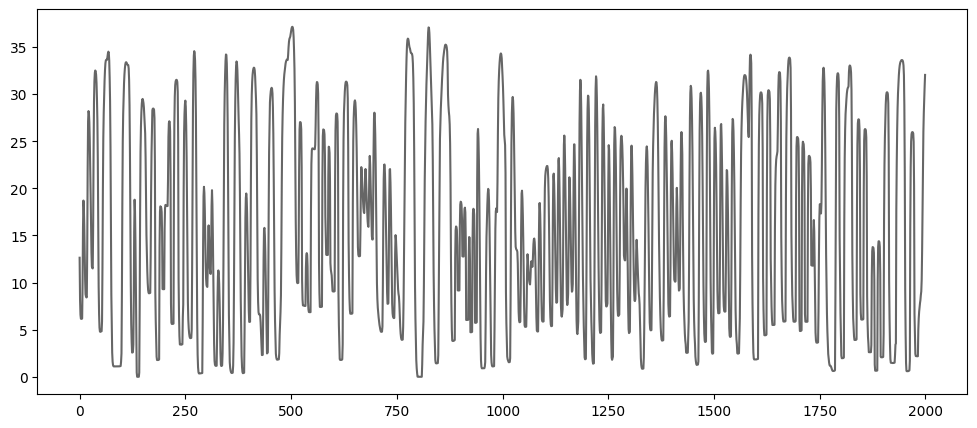

np.float64(0.31880904736707605)

In [21]:
plt.figure(figsize=(12, 5))
t, d = np.arange(len(waveform[1000:3000])), waveform[1000:3000]
plt.plot(t, d, label='CO2 (Filtered)', color='black', alpha=0.6)
plt.show()
compute_rhythm_score(waveform[1000:3000])

Searching top 8 PCA components...
  > PC1: Score=647.144, Shift=978.10s, Inverted=False
  > PC2: Score=903.516, Shift=399.35s, Inverted=True
  > PC3: Score=682.613, Shift=30.50s, Inverted=False
  > PC4: Score=707.242, Shift=390.10s, Inverted=False
  > PC5: Score=873.512, Shift=131.40s, Inverted=False
  > PC6: Score=763.849, Shift=868.90s, Inverted=False
  > PC7: Score=700.440, Shift=378.05s, Inverted=True
  > PC8: Score=770.810, Shift=383.20s, Inverted=True
Winner: PC2 (Shift: 399.350s)


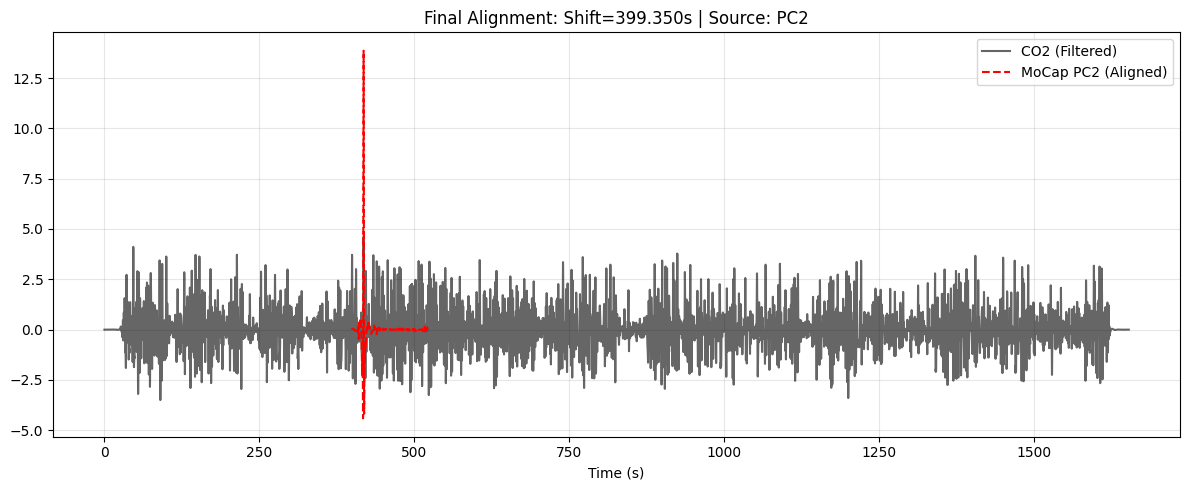

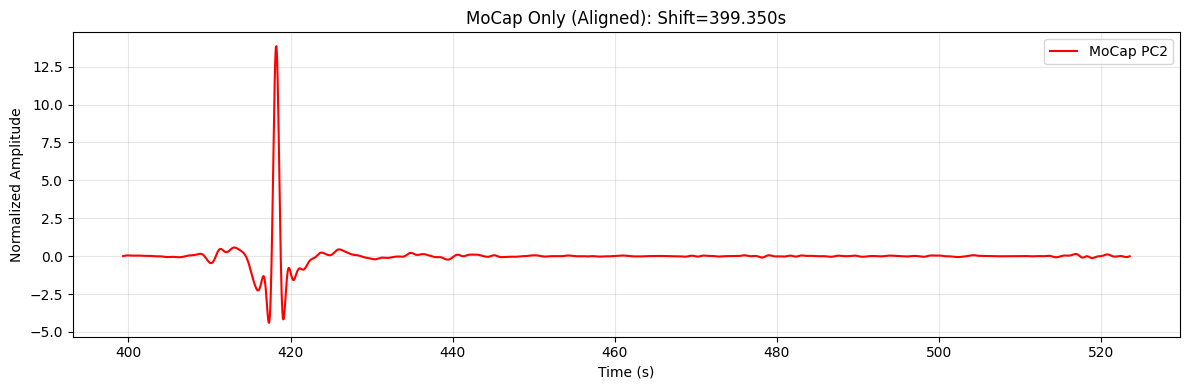

Shift MoCap by 399.35 seconds.


In [9]:
result = align_signals_robust(waveform, motion)
plot_final_alignment(waveform, motion, result)
print(f"Shift MoCap by {result['time_shift']} seconds.")